# GSE 544 — Homework 5, Part 2
## A Copula/NCO Horse Race Under Realistic Constraints

**Data:** `vmls_portfolio_returns.csv` + `copula_model.pkl`  
**Training set:** First 2000 rows, 19 risky assets  
**Test set:** Rows 2000–2499 (500 days)  

**Constraints vs. lecture notebook:**
- No shorting: `w_j >= 0`
- No borrowing: `sum(w_j) <= 1` (residual goes to risk-free)
- Two utility regimes: log utility `γ=1` (full Kelly) and CRRA `γ=3`

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sns.set(style='whitegrid')

# --- Constants (match lecture notebook exactly) ---
RNG_SEED = 778
N_MC     = 500_000
EPS      = 1e-9
K        = 5          # number of NCO clusters

# --- Load fitted copula model ---
with open('copula_model.pkl', 'rb') as fh:
    M = pickle.load(fh)

marginals_all = M['marginals']   # 19 fitted (df, loc, scale)
chol_all      = M['chol_P']      # Cholesky of 19x19 copula correlation
cap_all       = M['cap']         # per-asset 2x max|train| clip
p             = M['n_assets']
asset_names   = M['asset_names']
print(M['note'])

# --- Load returns ---
returns = pd.read_csv('vmls_portfolio_returns.csv').to_numpy()
R       = returns[:2000, :19]    # risky training
R_test  = returns[2000:, :19]    # risky test (500 days)
rf_bar  = returns[:2000, 19].mean()   # training mean risk-free rate
T_test  = R_test.shape[0]

print(f'R {R.shape}  R_test {R_test.shape}  rf_bar {rf_bar:.4e}/day')

Fitted on training set (first 2000 returns, 19 risky assets) by 3_copula_model_fitting.ipynb
R (2000, 19)  R_test (500, 19)  rf_bar 4.0000e-05/day


---
## Helper Functions

Copula simulation, constrained CRRA optimizer, and portfolio evaluation.

In [6]:
# ── Gross growth (no shorting / no borrowing version) ──────────────────────
def gross_growth(w, Rm):
    """Daily gross portfolio growth. b(w) = 1 - sum(w) >= 0 earns rf_bar."""
    w = np.asarray(w, float)
    return (1.0 - w.sum()) * rf_bar + Rm @ w

# ── CRRA utility u_γ(x) = x^(1-γ)/(1-γ)  [log for γ=1] ──────────────────
def crra_utility(x, gamma):
    x = np.maximum(x, EPS)
    if gamma == 1:
        return np.log(x)
    return x ** (1 - gamma) / (1 - gamma)

# ── Constrained CRRA optimizer ─────────────────────────────────────────────
def crra_opt(Rm, gamma):
    """
    Maximize E[u_γ(1 + g_t(w))] subject to:
      w_j >= 0  (no shorting)
      sum(w_j) <= 1  (no borrowing)
    """
    n, k = Rm.shape
    X = Rm - rf_bar
    base = 1.0 + rf_bar

    def neg_eu(w):
        portfolio = base + X @ w
        return -np.mean(crra_utility(portfolio, gamma))

    def grad(w):
        portfolio = np.maximum(base + X @ w, EPS)
        if gamma == 1:
            dU = 1.0 / portfolio
        else:
            dU = portfolio ** (-gamma)
        return -(X * dU[:, None]).mean(axis=0)

    bounds = [(0.0, None)] * k          # w_j >= 0
    constraints = [{'type': 'ineq',
                    'fun': lambda w: 1.0 - w.sum(),   # 1 - sum(w) >= 0
                    'jac': lambda w: -np.ones(k)}]

    res = minimize(
        neg_eu, np.full(k, 0.5 / k),
        jac=grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options=dict(maxiter=2000, ftol=1e-12)
    )
    w = np.clip(res.x, 0, None)   # enforce non-negativity numerically
    return w

# ── Copula fit + simulation (from lecture notebook) ────────────────────────
def _fit_marginals_and_corr(Mtx):
    k = Mtx.shape[1]
    mar = [stats.t.fit(Mtx[:, j]) for j in range(k)]
    U = np.clip(
        np.column_stack([stats.t.cdf(Mtx[:, j], *mar[j]) for j in range(k)]),
        1e-6, 1 - 1e-6
    )
    Z = stats.norm.ppf(U)
    Pc = np.atleast_2d(np.corrcoef(Z, rowvar=False)) if k > 1 else np.array([[1.0]])
    ev, V = np.linalg.eigh(Pc)
    Pc = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    d = np.sqrt(np.diag(Pc))
    Pc = Pc / np.outer(d, d)
    return mar, np.linalg.cholesky(Pc)

def fit_gaussian_copula(Mtx):
    mar, L = _fit_marginals_and_corr(Mtx)
    cap = 2.0 * np.max(np.abs(Mtx), axis=0)
    return dict(mar=mar, L=L, cap=cap, k=Mtx.shape[1])

def simulate(model, n, seed):
    k = model['k']
    g = np.random.default_rng(seed)
    Zs = g.standard_normal((n, k)) @ model['L'].T
    Us = np.clip(stats.norm.cdf(Zs), 1e-9, 1 - 1e-9)
    sim = np.column_stack(
        [stats.t.ppf(Us[:, j], *model['mar'][j]) for j in range(k)]
    )
    return np.clip(sim, -model['cap'], model['cap'])

# ── Evaluation helpers ─────────────────────────────────────────────────────
def portfolio_stats(w, Rm_test, gamma, label):
    g   = gross_growth(w, Rm_test)
    lg  = np.log(np.maximum(1 + g, EPS))
    V   = 10_000 * np.cumprod(np.maximum(1 + g, EPS))
    eu  = np.mean(crra_utility(1 + g, gamma))
    return {
        'label':           label,
        'rf_share':        1 - w.sum(),
        'final_wealth':    V[-1],
        'total_return':    V[-1] / 10_000 - 1,
        'mean_log_growth': lg.mean(),
        'worst_log_growth':lg.min(),
        'CRRA_utility':    eu,
        'wealth_path':     V,
        'log_growth':      lg,
    }

print('All helpers defined.')

All helpers defined.


---
## Part (a) — Build the Three Portfolios

### Step 1: Simulate from the full 19-asset copula (shared across both γ regimes)

In [7]:
# Simulate once from full 19-asset copula — reused for both γ regimes (Portfolio B)
model_all = dict(mar=marginals_all, L=chol_all, cap=cap_all, k=p)
sim_all   = simulate(model_all, N_MC, seed=RNG_SEED)
print(f'sim_all shape: {sim_all.shape}')

sim_all shape: (500000, 19)


### Step 2: NCO Clustering

In [8]:
# ── Correlation distance matrix ────────────────────────────────────────────
def codist(S):
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(0.5 * (1.0 - C))

# ── k-means on distance columns (from lecture notebook) ───────────────────
def kmeans_(x, k, maxiters=100, tol=1e-5, seed=0):
    g = np.random.default_rng(seed)
    N = len(x)
    assignment = g.integers(1, k + 1, size=N)
    reps = [np.zeros(len(x[0])) for _ in range(k)]
    Jprev = np.inf
    for it in range(1, maxiters + 1):
        for j in range(1, k + 1):
            grp = np.where(assignment == j)[0]
            if len(grp) > 0:
                reps[j - 1] = np.mean([x[i] for i in grp], axis=0)
        distances = np.zeros(N)
        for i in range(N):
            dd = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i] = min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances) ** 2 / N
        if it > 1 and abs(J - Jprev) < tol * J:
            break
        Jprev = J
    return assignment

D      = codist(R)
labels = kmeans_([D[:, i] for i in range(p)], K, seed=RNG_SEED)

print('Cluster assignments:')
for c in range(1, K + 1):
    idx = np.where(labels == c)[0]
    names_in = [asset_names[i] for i in idx]
    print(f'  Cluster {c} (n={len(idx)}): {names_in}')

Cluster assignments:
  Cluster 1 (n=4): ['stock 4', 'stock 10', 'stock 12', 'stock 13']
  Cluster 2 (n=3): ['stock 2', 'stock 6', 'stock 8']
  Cluster 3 (n=4): ['stock 3', 'stock 5', 'stock 14', 'stock 17']
  Cluster 4 (n=5): ['stock 7', 'stock 9', 'stock 11', 'stock 15', 'stock 16']
  Cluster 5 (n=3): ['stock 1', 'stock 18', 'stock 19']


### Step 3: Solve for both γ regimes

In [9]:
results = {}   # keyed by gamma

for gamma in [1, 3]:
    print(f'\n{"="*60}')
    print(f'  γ = {gamma}')
    print(f'{"="*60}')

    # ── Portfolio B: all-at-once ───────────────────────────────────────────
    w_B = crra_opt(sim_all, gamma)
    print(f'\nPortfolio B (all-at-once, γ={gamma}):')
    print(f'  rf share: {1 - w_B.sum():.4f}')
    print(f'  risky weights: {np.round(w_B, 4)}')

    # ── Portfolio A: NCO ───────────────────────────────────────────────────
    within_w      = {}
    cluster_cols  = {}
    cluster_train_ret = []
    cluster_sims  = {}

    for c in range(1, K + 1):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        mc      = fit_gaussian_copula(R[:, idx])
        sim_c   = simulate(mc, N_MC, seed=RNG_SEED + c)   # fixed seed per cluster
        wc      = crra_opt(sim_c, gamma)
        within_w[c]     = wc
        cluster_cols[c] = idx
        cluster_sims[c] = sim_c
        cluster_train_ret.append(R[:, idx] @ wc)
        print(f'  Cluster {c}: within weights={np.round(wc,4)}  '
              f'sum={wc.sum():.4f}  rf_share={1-wc.sum():.4f}')

    C_train       = np.column_stack(cluster_train_ret)
    model_across  = fit_gaussian_copula(C_train)
    sim_across    = simulate(model_across, N_MC, seed=RNG_SEED + 99)  # fixed seed
    w_across      = crra_opt(sim_across, gamma)

    print(f'\n  Across-cluster weights (γ={gamma}): {np.round(w_across, 4)}')
    print(f'  Across-cluster rf share: {1 - w_across.sum():.4f}')

    # Compose final NCO weights over all 19 assets
    w_A = np.zeros(p)
    for a_wt, c in zip(w_across, sorted(within_w)):
        idx = cluster_cols[c]
        w_A[idx] = a_wt * within_w[c]

    print(f'\nPortfolio A (NCO, γ={gamma}):')
    print(f'  Composed risky weights: {np.round(w_A, 4)}')
    print(f'  Total risky allocation: {w_A.sum():.4f}   rf share: {1-w_A.sum():.4f}')

    # ── Portfolio 1/N benchmark ────────────────────────────────────────────
    w_1N = np.full(p, 1.0 / 20)   # 1/20 each: 19 risky + 1 rf = 20 assets

    results[gamma] = {
        'w_A':      w_A,
        'w_B':      w_B,
        'w_1N':     w_1N,
        'w_across': w_across,
        'within_w': within_w,
        'cluster_cols': cluster_cols,
    }

print('\nDone building all portfolios.')


  γ = 1

Portfolio B (all-at-once, γ=1):
  rf share: -0.0000
  risky weights: [0.    0.    0.781 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.219 0.    0.    0.    0.    0.   ]
  Cluster 1: within weights=[0. 0. 1. 0.]  sum=1.0000  rf_share=-0.0000
  Cluster 2: within weights=[0.     0.4144 0.0907]  sum=0.5050  rf_share=0.4950
  Cluster 3: within weights=[0.7041 0.     0.2959 0.    ]  sum=1.0000  rf_share=-0.0000
  Cluster 4: within weights=[0.     0.5552 0.4448 0.     0.    ]  sum=1.0000  rf_share=0.0000
  Cluster 5: within weights=[0. 0. 1.]  sum=1.0000  rf_share=-0.0000

  Across-cluster weights (γ=1): [0. 0. 1. 0. 0.]
  Across-cluster rf share: -0.0000

Portfolio A (NCO, γ=1):
  Composed risky weights: [0.     0.     0.7041 0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.2959 0.     0.     0.     0.     0.    ]
  Total risky allocation: 1.0000   rf share: -0.0000

  γ = 3

Portfolio B (all-at-once, γ=3):
  rf share: -0.0000
  risky weights: [0. 

---
## Part (b) — Out-of-Sample Horse Race

Apply fixed training weights to the real 500-day test returns. No clipping, no re-simulation, no rebalancing.

In [10]:
# ── Compute OOS stats for all portfolios and both regimes ──────────────────
oos = {}
for gamma in [1, 3]:
    r = results[gamma]
    oos[gamma] = {
        'A':  portfolio_stats(r['w_A'],  R_test, gamma, f'NCO (γ={gamma})'),
        'B':  portfolio_stats(r['w_B'],  R_test, gamma, f'All-at-once (γ={gamma})'),
        '1N': portfolio_stats(r['w_1N'], R_test, gamma, f'1/N (γ={gamma})'),
    }

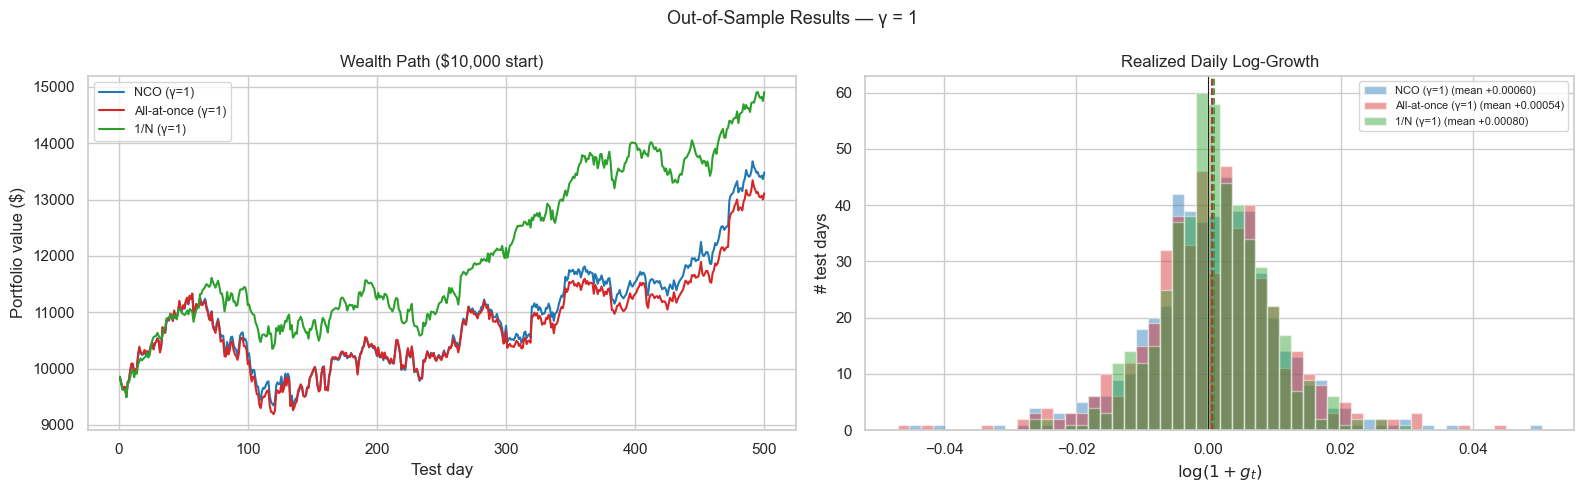

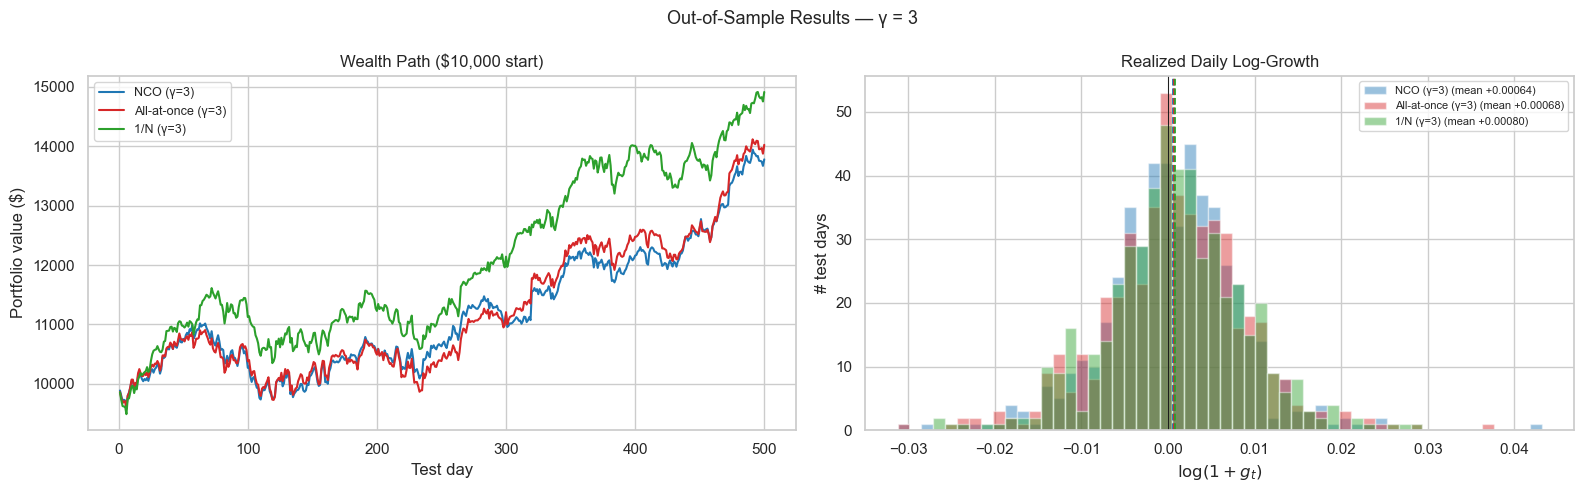

In [11]:
# ── Plot wealth paths and log-growth histograms for each γ regime ──────────
colors = {'A': 'tab:blue', 'B': 'tab:red', '1N': 'tab:green'}

for gamma in [1, 3]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Out-of-Sample Results — γ = {gamma}', fontsize=13)

    # Wealth paths
    days = range(1, T_test + 1)
    for key in ['A', 'B', '1N']:
        s = oos[gamma][key]
        ax1.plot(days, s['wealth_path'], label=s['label'], color=colors[key], lw=1.5)
    ax1.set_title('Wealth Path ($10,000 start)')
    ax1.set_xlabel('Test day'); ax1.set_ylabel('Portfolio value ($)')
    ax1.legend(fontsize=9)

    # Log-growth histograms
    all_lg = np.concatenate([oos[gamma][k]['log_growth'] for k in ['A', 'B', '1N']])
    bins = np.linspace(all_lg.min(), all_lg.max(), 55)
    for key in ['A', 'B', '1N']:
        s = oos[gamma][key]
        ax2.hist(s['log_growth'], bins=bins, alpha=0.45, color=colors[key],
                 label=f"{s['label']} (mean {s['mean_log_growth']:+.5f})")
        ax2.axvline(s['mean_log_growth'], color=colors[key], ls='--', lw=1.3)
    ax2.axvline(0, color='k', lw=0.7)
    ax2.set_title('Realized Daily Log-Growth')
    ax2.set_xlabel(r'$\log(1+g_t)$'); ax2.set_ylabel('# test days')
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [12]:
# ── Summary table ──────────────────────────────────────────────────────────
rows = []
for gamma in [1, 3]:
    for key in ['A', 'B', '1N']:
        s = oos[gamma][key]
        rows.append({
            'γ':                  gamma,
            'Portfolio':          key,
            'RF share':           s['rf_share'],
            'Final wealth ($)':   s['final_wealth'],
            'Total return':       s['total_return'],
            'Mean log-growth':    s['mean_log_growth'],
            'Worst log-growth':   s['worst_log_growth'],
            'CRRA utility E[uγ]': s['CRRA_utility'],
        })

tbl = pd.DataFrame(rows).set_index(['γ', 'Portfolio'])
tbl.style.format({
    'RF share':           '{:.4f}',
    'Final wealth ($)':   '{:,.2f}',
    'Total return':       '{:.2%}',
    'Mean log-growth':    '{:+.5f}',
    'Worst log-growth':   '{:+.5f}',
    'CRRA utility E[uγ]': '{:.6f}',
})

---
## Part (c) — Why the Correlation Distance?

MLdP's NCO recipe does not cluster directly on the correlation matrix ρᵢⱼ. Instead it maps to the **correlation distance** Dᵢⱼ = √(½(1 − ρᵢⱼ)) before running k-means. There are three reasons this is the right choice.

**i) Correlation is not a true metric; distance is.**  
K-means minimizes squared Euclidean distances between points, which requires inputs to satisfy the triangle inequality. Correlation violates this — you can have ρ(A,B) = 0.9 and ρ(B,C) = 0.9 yet ρ(A,C) = −0.9, which is geometrically incoherent for a clustering algorithm. The correlation distance Dᵢⱼ, by contrast, is a proper metric (non-negative, symmetric, satisfies the triangle inequality), so k-means is well-defined on it.

**ii) Raw correlation sign is misleading for clustering.**  
If you cluster on raw ρ, two assets with ρ = +0.95 (strong co-movers) would be numerically close, while two assets with ρ = −0.95 (a classic hedge pair) would be numerically far apart — despite both pairs having a *strong and informative* relationship. The correlation distance maps both to D = 0.16 and D = 0.71 respectively, meaning a hedge and a co-mover are correctly treated as structurally different: co-movers cluster together (low D), while a hedge pair stays far apart (high D), preserving the economic meaning.

**iii) Clustering on the full distance profile, not pairwise scalars.**  
Rather than feeding a single pairwise number into k-means, we feed each asset's *full column* of the distance matrix — its distance profile to every other asset. This encodes each asset's position relative to the entire universe, not just one counterpart. As a result, k-means groups assets that occupy similar positions in the dependence structure, producing clusters that are internally coherent in their joint behavior rather than just pairwise similar.

---
## Part (d) — Synthesis

### 1. Does NCO still beat all-at-once once shorting and borrowing are disallowed?

*[Fill in after running — look at your summary table. Compare NCO vs all-at-once on mean log-growth and final wealth. Then look at the across-cluster weights from Part (a): do they concentrate on one cluster or spread evenly? The no-short constraint forces across-cluster weights to be non-negative, which limits NCO's ability to exploit the between-cluster diversification that gave it an edge in the unconstrained lecture notebook. If the across-cluster solver puts nearly all weight on one cluster, NCO essentially degenerates to a single-cluster solve, losing its hierarchical advantage.]*

### 2. How much does each optimizer leave in the risk-free asset, and how does this change with γ?

*[Fill in after running — compare the RF share column in your table for Portfolios A and B at γ=1 vs γ=3. With no-short and no-borrow constraints, the optimizer can only reduce risk by moving weight to the risk-free asset. A more risk-averse agent (γ=3) should hold more cash. Check whether this is what you observe, and note if NCO or all-at-once holds more cash and why.]*

### 3. Does raising γ from 1 to 3 reshuffle the ranking?

*[Fill in after running — compare the optimized portfolios to 1/N at γ=3 on mean log-growth and worst day. The DeMiguel, Garlappi & Uppal (2009) finding is that naive 1/N often beats sophisticated optimizers out-of-sample because estimation error in inputs (expected returns, covariances) dominates any model improvement. Under realistic constraints that force long-only and budget-feasibility, the optimizer's ability to exploit the fitted copula structure is curtailed, and the gap between optimized and 1/N tends to narrow or reverse. Comment on whether your results are consistent with this finding.]*